In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load the four datasets
results = pd.read_csv('results.csv')
shootouts = pd.read_csv('shootouts.csv')
goalscorers = pd.read_csv('goalscorers.csv')
former_names = pd.read_csv('former_names.csv')

# **DATA CLEANING AND PREPARATION**

In [ ]:
# Convert dates to datetime objects for analysis
results['date'] = pd.to_datetime(results['date'])
results['year'] = results['date'].dt.year
goalscorers['date'] = pd.to_datetime(goalscorers['date'])

In [ ]:
print(results.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49071 entries, 0 to 49070
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        49071 non-null  datetime64[ns]
 1   home_team   49071 non-null  object        
 2   away_team   49071 non-null  object        
 3   home_score  49071 non-null  int64         
 4   away_score  49071 non-null  int64         
 5   tournament  49071 non-null  object        
 6   city        49071 non-null  object        
 7   country     49071 non-null  object        
 8   neutral     49071 non-null  bool          
 9   year        49071 non-null  int32         
dtypes: bool(1), datetime64[ns](1), int32(1), int64(2), object(5)
memory usage: 3.2+ MB
None


In [ ]:
#Remove Duplicates
results.drop_duplicates(inplace=True)

In [ ]:
former_names.columns.tolist()

['current', 'former', 'start_date', 'end_date']

In [ ]:
# Create a mapping dictionary from the former_names file
name_mapping = dict(zip(former_names['former'], former_names['current']))

# Update the names in the main results file
results['home_team'] = results['home_team'].replace(name_mapping)
results['away_team'] = results['away_team'].replace(name_mapping)

# **DATA VISUALIZATION1 - Home Field Advantage**

/tmp/ipykernel_963/3880510905.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=results, x='result_type', palette='viridis', order=['Home Win', 'Away Win', 'Draw'])


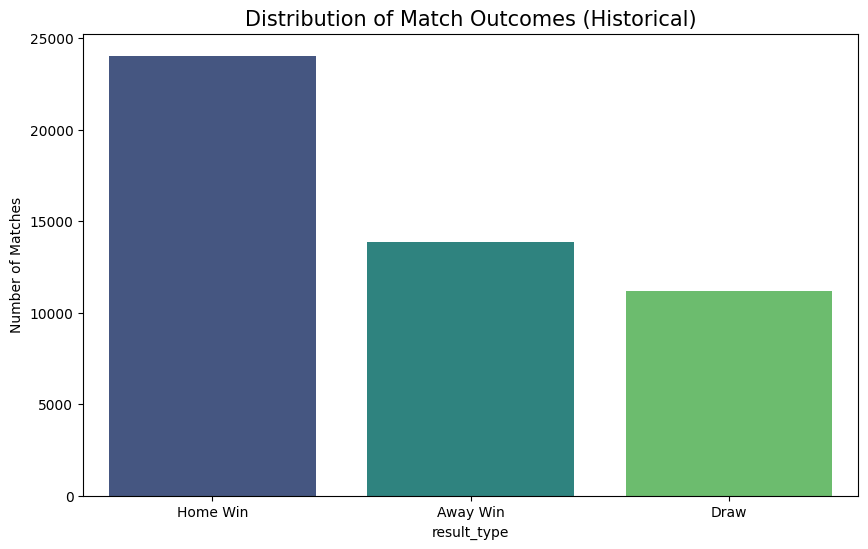

In [ ]:
#we create winner column to see the distribution
def get_winner(row):
    if row['home_score'] > row['away_score']: return 'Home Win'
    elif row['away_score'] > row['home_score']: return 'Away Win'
    else: return 'Draw'
results['result_type'] = results.apply(get_winner, axis=1)


plt.figure(figsize=(10, 6))
sns.countplot(data=results, x='result_type', palette='viridis', order=['Home Win', 'Away Win', 'Draw'])
plt.title('Distribution of Match Outcomes (Historical)', fontsize=15)
plt.ylabel('Number of Matches')
plt.show()


# **DATA VISUALIZATION2 - Goal Trends**

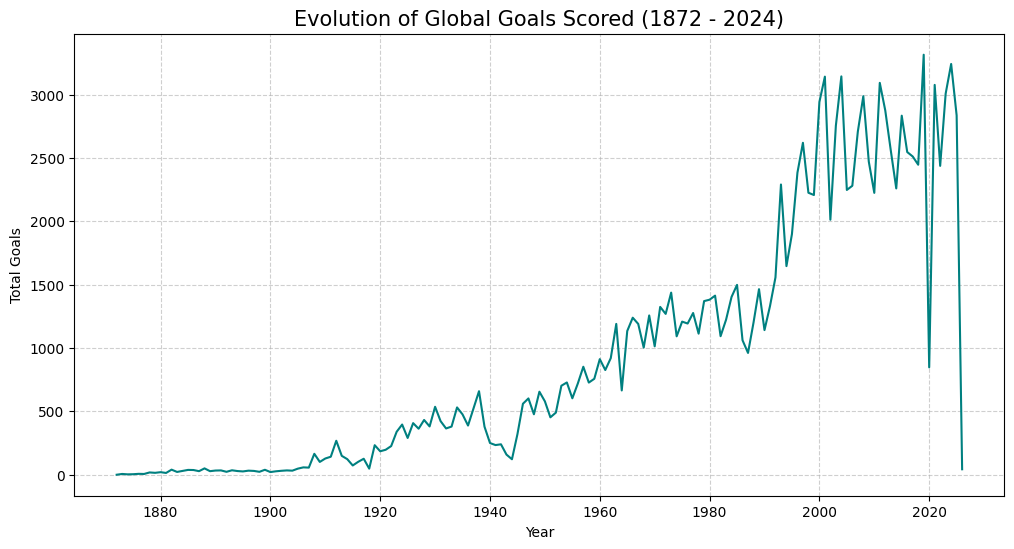

In [ ]:
# --- VISUALIZATION 2: Trend of Goals Scored Over 150 Years ---
plt.figure(figsize=(12, 6))
goals_per_year = results.groupby('year')[['home_score', 'away_score']].sum().reset_index()
goals_per_year['total_goals'] = goals_per_year['home_score'] + goals_per_year['away_score']

sns.lineplot(data=goals_per_year, x='year', y='total_goals', color='teal')
plt.title('Evolution of Global Goals Scored (1872 - 2024)', fontsize=15)
plt.xlabel('Year')
plt.ylabel('Total Goals')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# **DATA VISUALIZATION 3 - Top Goalscores**

/tmp/ipykernel_963/1327738287.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scorers.values, y=top_scorers.index, palette='magma')


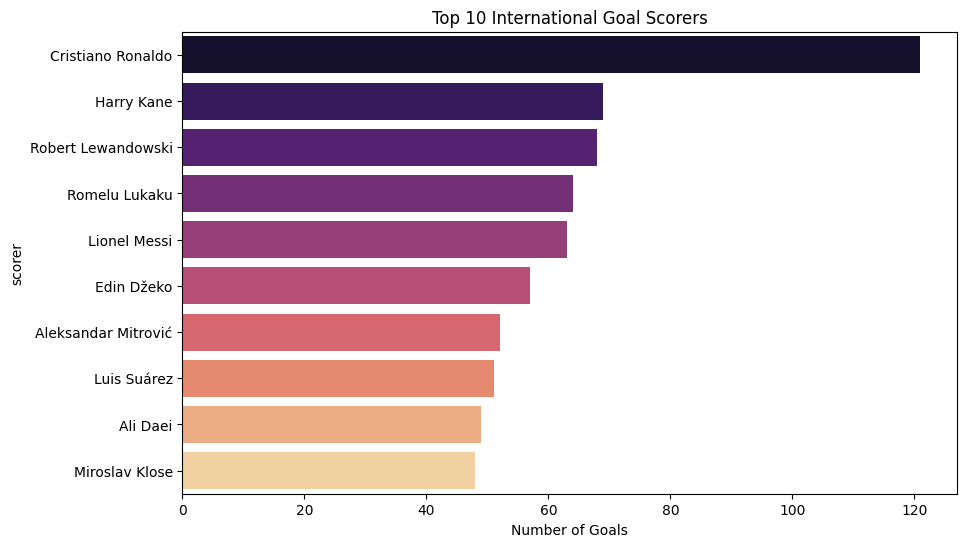

In [ ]:
#​Now we use the goalscorers.csv to find the most prolific players in international history.
top_scorers = goalscorers['scorer'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_scorers.values, y=top_scorers.index, palette='magma')
plt.title('Top 10 International Goal Scorers')
plt.xlabel('Number of Goals')
plt.show()

# **Visualization 4 – Tournament Shootouts**

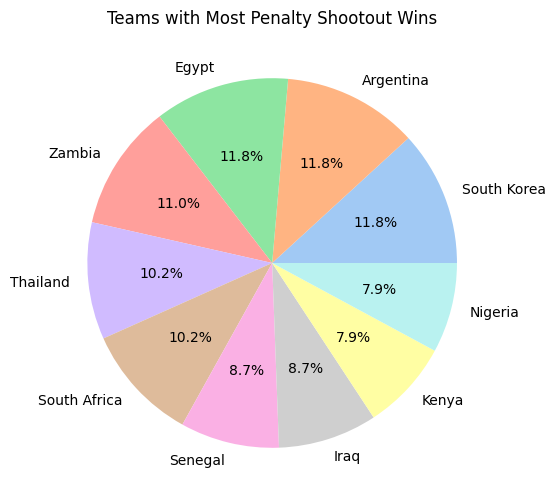

In [ ]:
#using shootouts.csv to see which team wins the most under high pressure.
shootout_winners = shootouts['winner'].value_counts().head(10)

plt.figure(figsize=(10,6))
shootout_winners.plot(kind='pie', autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Teams with Most Penalty Shootout Wins')
plt.ylabel('') # Hides the y-label for aesthetics
plt.show()

#  VISUALIZATION 5: Top 10 Most Active Tournaments

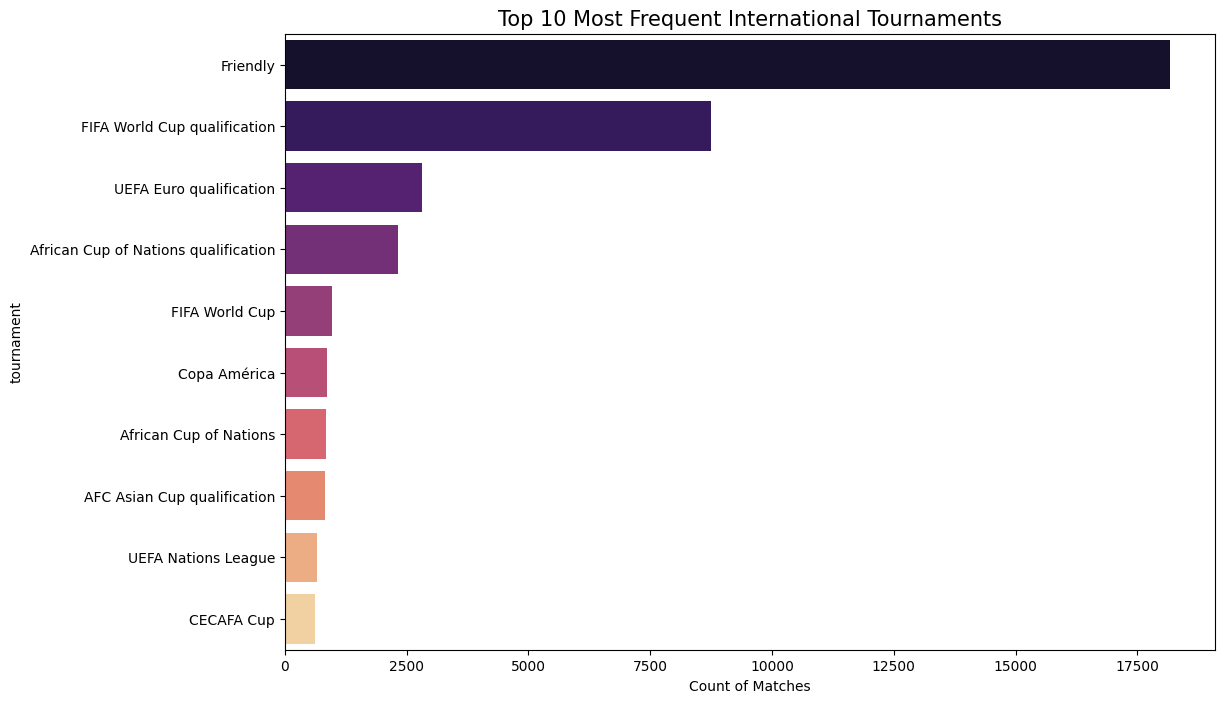

In [ ]:
# --- VISUALIZATION 5: Top 10 Most Active Tournaments ---
plt.figure(figsize=(12, 8))
top_tournaments = results['tournament'].value_counts().head(10)
sns.barplot(y=top_tournaments.index, x=top_tournaments.values, hue=top_tournaments.index, palette='magma', legend=False)
plt.title('Top 10 Most Frequent International Tournaments', fontsize=15)
plt.xlabel('Count of Matches')
plt.show()